In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
import random
import math
from mpmath import invertlaplace, mp

In [2]:
def incidence_matrix(edges, nodes):

    num_edges = len(edges)
    num_nodes = len(nodes)
    
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    delta = np.zeros((num_edges, num_nodes), dtype=int)
    
    for i, (u, v) in enumerate(edges):
        delta[i, node_to_idx[u]] = -1
        delta[i, node_to_idx[v]] = 1
    
    
    return delta, node_to_idx

In [3]:
def weighted_incidence_matrix(delta):
    Beta = np.zeros((num_edges, num_nodes), dtype=float)
    for i in delta:
        for j in i:
            if j == -1:
                B[i, j] = compute_front_node()
            elif j == 1:
                B[i, j] = compute_back_node()
            continue
    

In [4]:
def solve_laplacian(delta, A, B, V, K, P, p_0, theta):
    
    Q_s = ((1 - theta) * B + theta * A) * V
    L = delta.T@K@delta
    N = L.shape[0]
    
    rhs = delta.T@Q_s
     
    L_bar = L[1:, 1:]
    rhs_bar = rhs[1:] - L[1:, 0] * p_0
    P_bar = np.linalg.solve(L_bar, rhs_bar)

    P = np.zeros(N)
    P[0] = p_0
    P[1:] = P_bar

    return P, L

In [5]:
def calculate_flow(delta, A, B, K, V, P, theta):
    K_1D = np.diag(K) if K.ndim == 2 else K    # force 1D
    Q_s = ((1 - theta) * B + theta * A) * V
    Q_w = Q_s - K_1D * (delta @ P)
    return Q_w

In [6]:
def calculate_core_flow(delta, A, K, V, P):
    K_1D = np.diag(K) if K.ndim == 2 else K
    Q_inner = A**2 * V - K_1D * (delta @ P)
    Q_inner = A * V - K_1D * (delta @ P)
    return Q_inner

In [7]:
def compute_lipid_flows(G, edges, node_to_idx, Q_total):
    """
    Computes lipid flow on each edge by the 50/50 equipartition rule.
    Q_total is the total lipid flow entering the network at the root.
    Returns Q_lipid: array of lipid flow rates per edge.
    """
    num_edges = len(edges)
    Q_lipid = np.zeros(num_edges)
    
    # count number of downstream leaves for each node
    def count_leaves(node):
        children = list(G.successors(node))
        if len(children) == 0:
            return 1  # is a leaf
        return sum(count_leaves(c) for c in children)
    
    # assign flow to each edge proportional to downstream leaves
    total_leaves = count_leaves(0)  # total leaves from root
    
    for e_idx, (i, j) in enumerate(edges):
        downstream = count_leaves(j)
        Q_lipid[e_idx] = Q_total * downstream / total_leaves
    
    return Q_lipid

**BUILDING COMPLEX NETWORKS**

In [44]:
#Stochastic network

# Parameters
max_depth = 3        # maximum levels of branching
branch_prob = 0.7     # probability each node bifurcates
G = nx.DiGraph()
G.add_node(0)         # root node
num_nodes = 1
num_edges = 0

F = np.empty(0)
B = 1.0

# Build network
for depth in range(max_depth):
    nodes_at_level = [n for n in G.nodes if nx.shortest_path_length(G, 0, n) == depth]
    for parent in nodes_at_level:
        has_Kids = False
        # Each node has a chance to bifurcate
        if depth != max_depth-1:
            for i in range(2):
                if random.random() < branch_prob:
                    G.add_node(num_nodes)
                    G.add_edge(parent, num_nodes)
                    has_Kids = True
                    num_nodes += 1
                    num_edges += 1

        if not has_Kids or depth == max_depth-1:
            F = np.append(F, B)
        else:
            F = np.append(F, 0)
        
            

print(F)
print(G.edges)
edges = list(G.edges)
nodes = list(G.nodes)

# calculate incidence matrix
delta, node_to_idx = incidence_matrix(edges, nodes)

# initialize area and conductivity matrices
theta = 0.1
B = np.full(num_edges, 1.0)
L_edge = np.full(num_edges, 1.0)

P = np.zeros(num_nodes)
p0 = 0.0

V = np.full(num_edges, 1.0)
n_root_edges = sum(1 for u, _ in edges if u == 0)
Q_total = theta * V[0] * B[0] * n_root_edges
print("Q_total:", Q_total)
Q_lipid_raw = compute_lipid_flows(G, edges, node_to_idx, Q_total)

# Keep motor velocity uniform and infer inner radius A from lipid demand.
# Q^l = (B - A) * theta * V  =>  A = B - Q^l / (theta * V)
A_min = 0.6
A_max = 0.95
A_root = 0.85  # baseline inner radius on root-connected edges

# Scale demand only if needed so inferred A stays within [A_min, B).
Q_lipid_cap = theta * V * (B - A_min)
safe_den = np.maximum(Q_lipid_raw, 1e-12)
alpha = min(1.0, np.min(Q_lipid_cap / safe_den))
Q_lipid = alpha * Q_lipid_raw

# Demand-implied radius profile.
A_demand = B - Q_lipid / (theta * V)
print("A_demand:", A_demand)
#A_demand = B - Q_lipid_raw / (theta * V)

# now solve for pressures and water flow
A = A_demand
K = A**2/L_edge
P_sol, L = solve_laplacian(delta, A, B, V, np.diag(K), P, p0, theta)

Q_w = calculate_flow(delta, A, B, K, V, P_sol, theta)
Q_core = calculate_core_flow(delta, A, K, V, P_sol)

print("Motor Velocities:", V)
print(f"Demand scaling alpha: {alpha:.4f}")
print(f"Root-edge baseline A_root: {A_root:.4f}")
print(f"A range: [{A.min():.4f}, {A.max():.4f}]")
print(f"K range: [{K.min():.4e}, {K.max():.4e}]")
print("Incidence matrix (Δ):\n", delta)
print("Area matrix (A):\n", A)
#print("Laplacian (L):\n", L)
print("Pressures (P):", P_sol)
print("Total flows (Q_w):", Q_w)
print("Core  flows (Q_core):", Q_core)

[0. 0. 0. 1. 1. 1. 1.]
[(0, 1), (0, 2), (1, 3), (1, 4), (2, 5), (2, 6)]
Q_total: 0.2
A_demand: [0.6 0.6 0.8 0.8 0.8 0.8]
Motor Velocities: [1. 1. 1. 1. 1. 1.]
Demand scaling alpha: 0.4000
Root-edge baseline A_root: 0.8500
A range: [0.6000, 0.8000]
K range: [3.6000e-01, 6.4000e-01]
Incidence matrix (Δ):
 [[-1  1  0  0  0  0  0]
 [-1  0  1  0  0  0  0]
 [ 0 -1  0  1  0  0  0]
 [ 0 -1  0  0  1  0  0]
 [ 0  0 -1  0  0  1  0]
 [ 0  0 -1  0  0  0  1]]
Area matrix (A):
 [0.6 0.6 0.8 0.8 0.8 0.8]
Pressures (P): [0.         2.66666667 2.66666667 4.19791667 4.19791667 4.19791667
 4.19791667]
Total flows (Q_w): [ 3.33066907e-16  2.22044605e-16  1.11022302e-16  1.11022302e-16
  4.44089210e-16 -1.11022302e-16]
Core  flows (Q_core): [-0.36 -0.36 -0.18 -0.18 -0.18 -0.18]


In [27]:
# Organic hierarchical layout
def mycelium_pos(G, root=0, x=0, y=0, x_offset=1.0, y_gap=1.0, pos=None):
    """
    Recursive layout mimicking mycelial growth.
    """
    if pos is None:
        pos = {root: (x, y)}
    children = list(G.successors(root))
    n_children = len(children)
    if n_children > 0:
        # Randomize horizontal spread for organic look
        spread = x_offset * random.uniform(0.5, 1.5)
        x_start = x - spread/2
        for i, child in enumerate(children):
            new_x = x_start + i * spread / max(n_children-1, 1)
            new_y = y - y_gap
            pos[child] = (new_x, new_y)
            mycelium_pos(G, child, new_x, new_y, x_offset*0.7, y_gap, pos)
    return pos

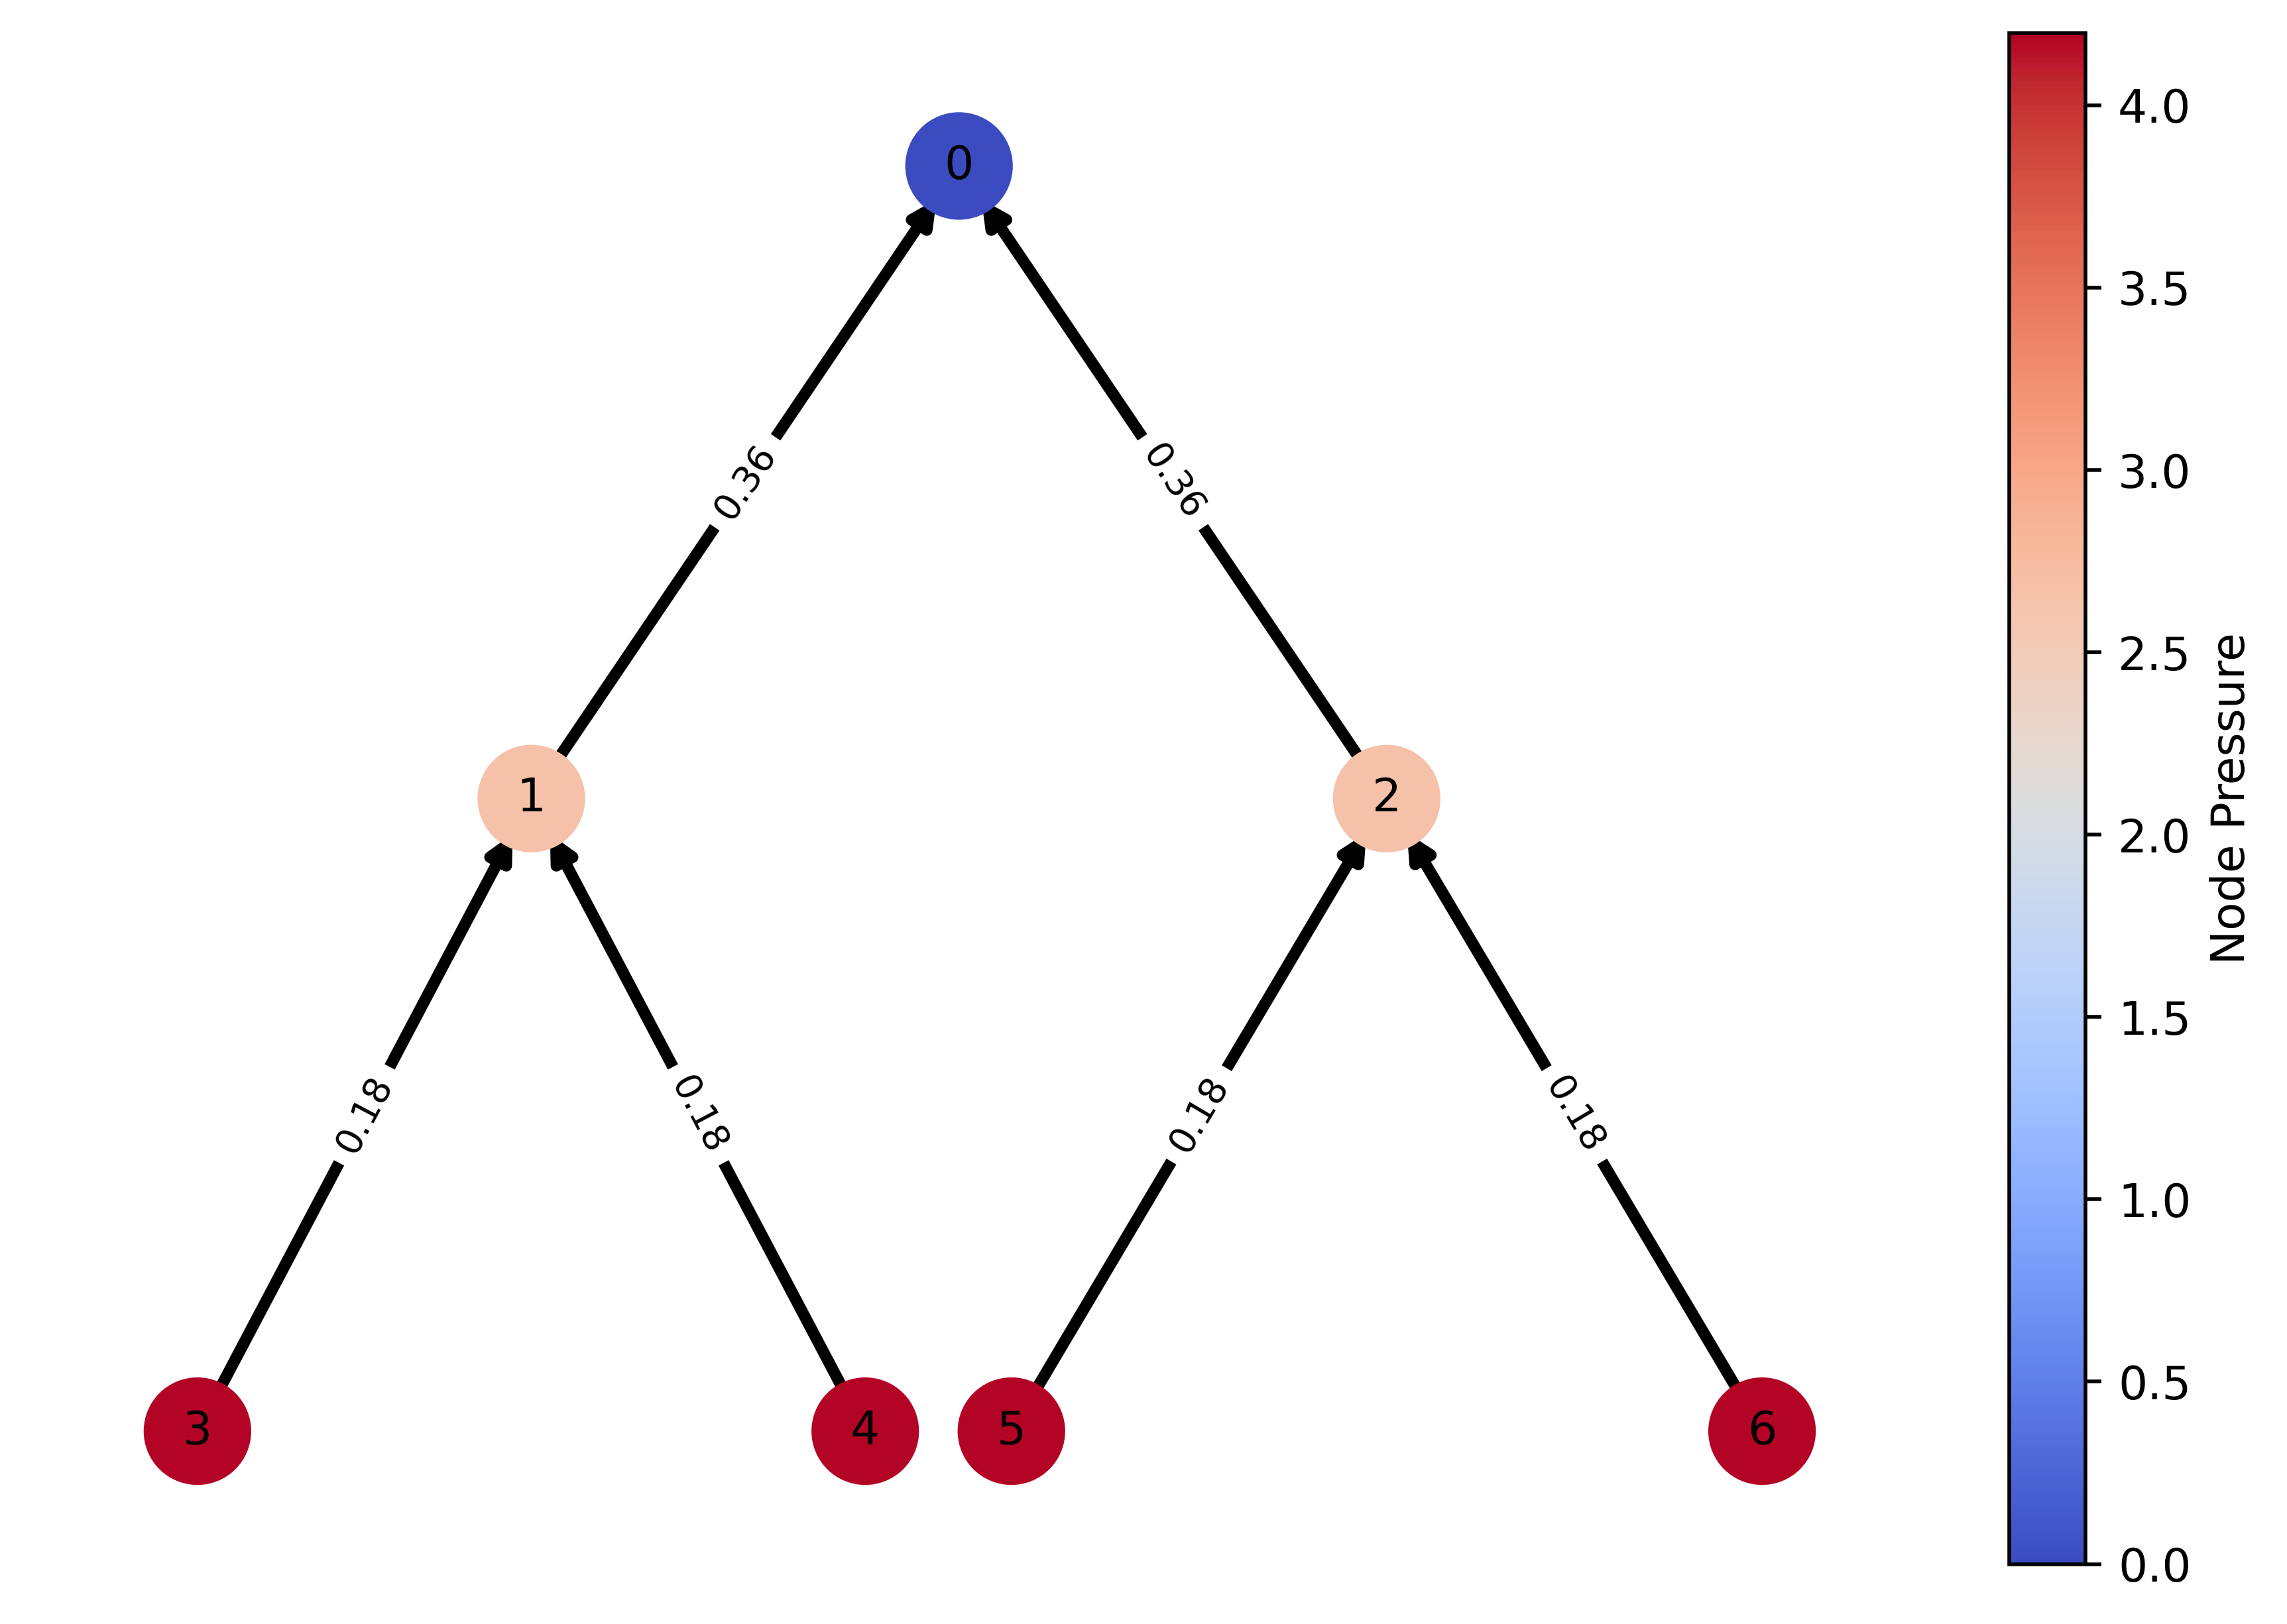

In [50]:
pos = mycelium_pos(G, root=0, x=0, y=0, x_offset=4.0, y_gap=1.0)

#----- 
# Suppose P_sol and edge_values already computed
node_values = [P_sol[n] for n in G.nodes]  # pressure at each node
edge_values = np.array(Q_core)  # or A, K, or Q (length = num_edges)

# --- NODE COLOR SETUP ---
node_cmap = plt.cm.coolwarm
node_norm = plt.Normalize(vmin=min(node_values), vmax=max(node_values))

# --- EDGE COLOR SETUP ---
edge_cmap = plt.cm.viridis
edge_norm = plt.Normalize(vmin=edge_values.min(), vmax=edge_values.max())
edge_colors = edge_cmap(edge_norm(edge_values))

fig, ax = plt.subplots(figsize=(7, 5))

# draw nodes w pressure
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_values,
    cmap=node_cmap,
    node_size=500,
    ax=ax
)

# Build flow-directed edges so arrows follow sign(edge_values).
# If value < 0, flip (u,v) -> (v,u).
flow_edges = []
flow_edge_values = []
for (u, v), val in zip(G.edges(), edge_values):
    if val >= 0:
        flow_edges.append((u, v))
        flow_edge_values.append(val)
    else:
        flow_edges.append((v, u))
        flow_edge_values.append(-val)  # flip sign so value matches drawn arrow direction

# draw edges
nx.draw_networkx_edges(
    G, pos,
    edgelist=flow_edges,
    #edge_color=edge_colors,
    width=2.5,
    arrows=True,
    ax=ax
)

# draw labels
nx.draw_networkx_labels(G, pos, font_color='black', font_size=10, ax=ax)

# edge labels (placed on drawn arrow direction)
edge_labels = {edge: f"{val:.2f}" for edge, val in zip(flow_edges, flow_edge_values)}
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_color='black',
    font_size=8,
    ax=ax
)

# node colorbar
sm_nodes = plt.cm.ScalarMappable(cmap=node_cmap, norm=node_norm)
sm_nodes.set_array([])
cbar_nodes = fig.colorbar(sm_nodes, ax=ax, fraction=0.046, pad=0.04)
cbar_nodes.set_label('Node Pressure')

"""
# edge colorbar
sm_edges = plt.cm.ScalarMappable(cmap=edge_cmap, norm=edge_norm)
sm_edges.set_array([])
cbar_edges = fig.colorbar(sm_edges, ax=ax, fraction=0.046, pad=0.08)
cbar_edges.set_label('Edge Value (e.g., Flow Q)')
"""

plt.axis('off')
plt.rcParams['figure.dpi'] = 500 # For inline display in notebook
plt.tight_layout()
plt.show()

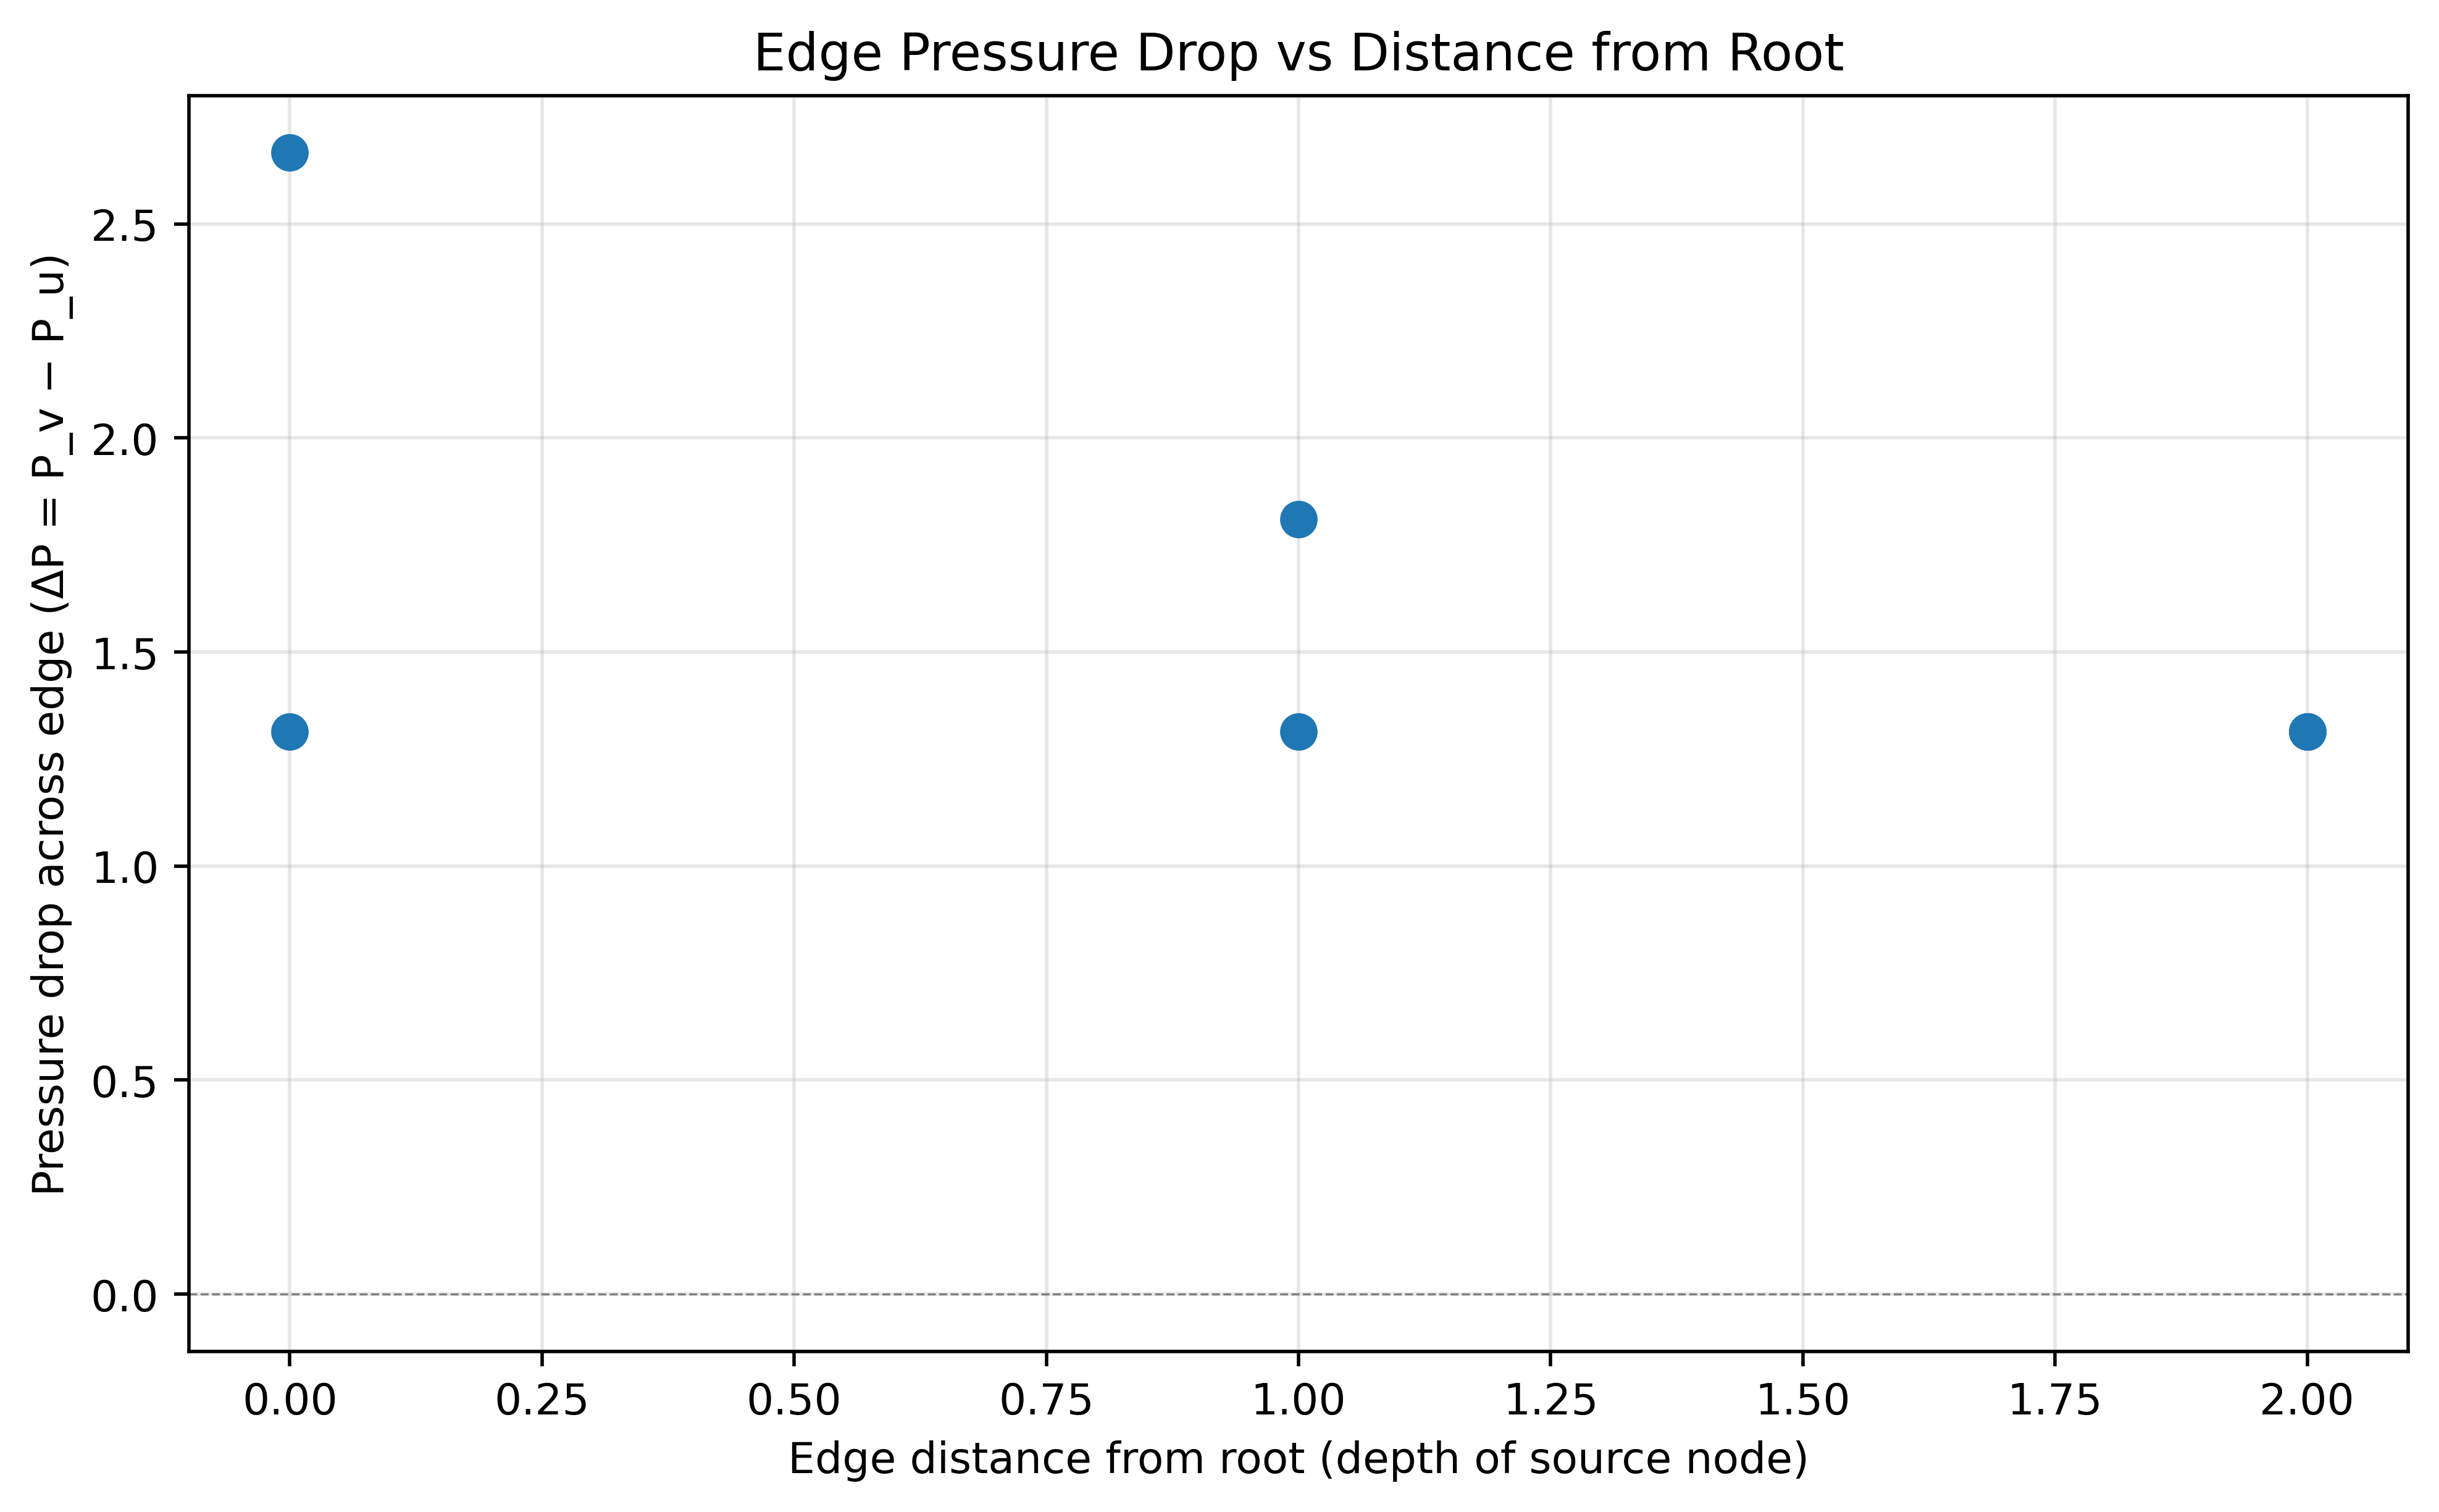

In [319]:
edge_pressures = delta @ P_sol

edge_depth = np.array([nx.shortest_path_length(G, 0, u) for u, v in edges])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(edge_depth, edge_pressures, s=60, zorder=3)

ax.set_xlabel("Edge distance from root (depth of source node)")
ax.set_ylabel("Pressure drop across edge (ΔP = P_v − P_u)")
ax.set_title("Edge Pressure Drop vs Distance from Root")
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()